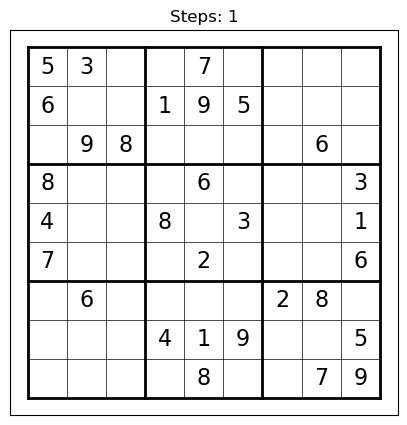

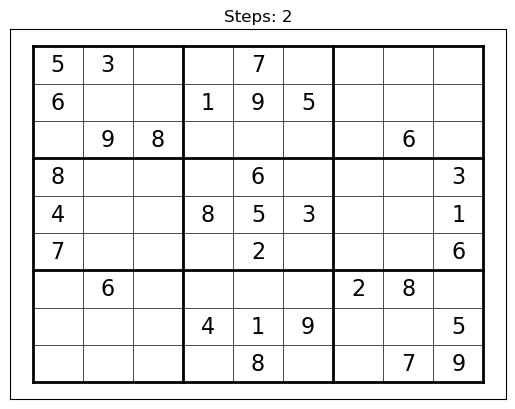

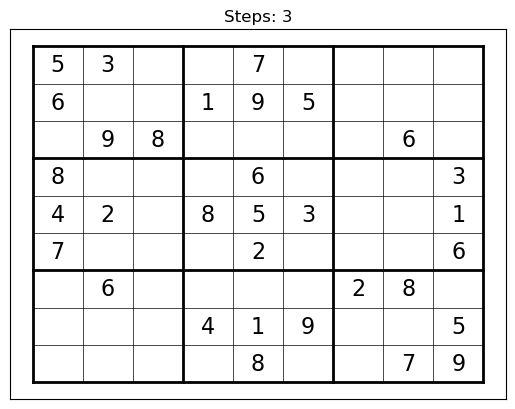

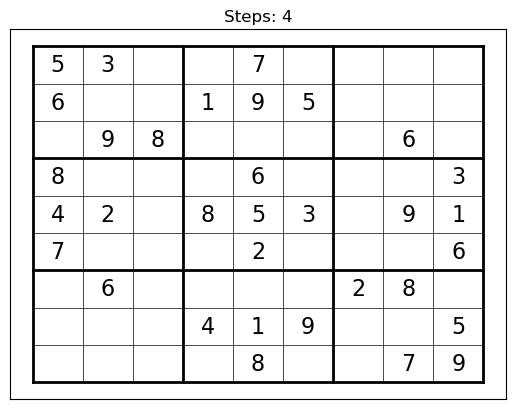

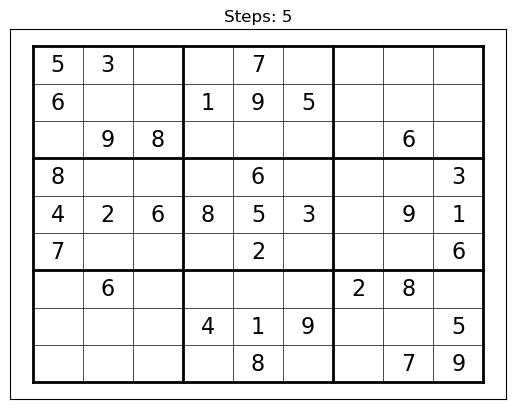

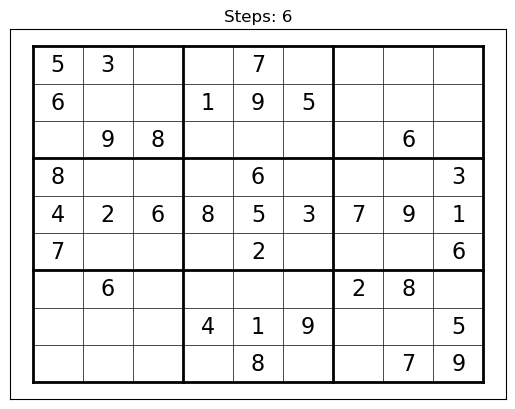

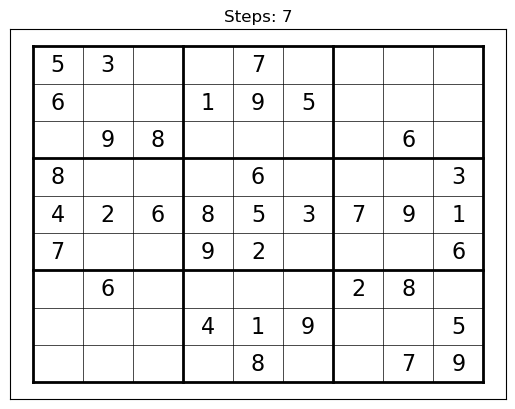

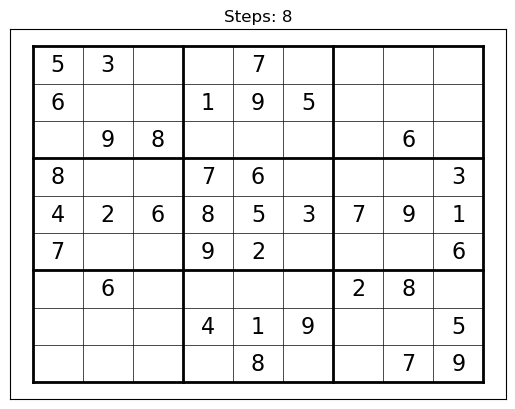

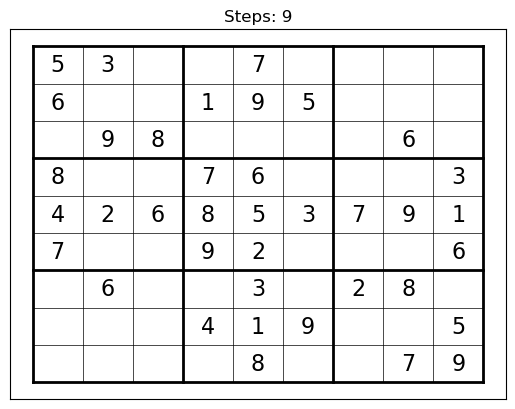

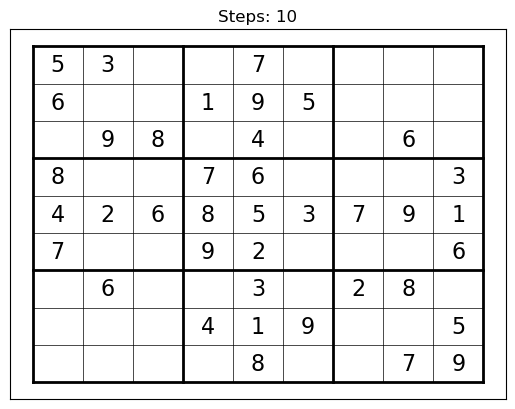

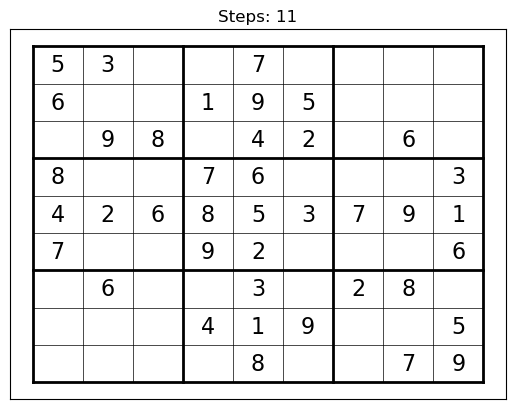

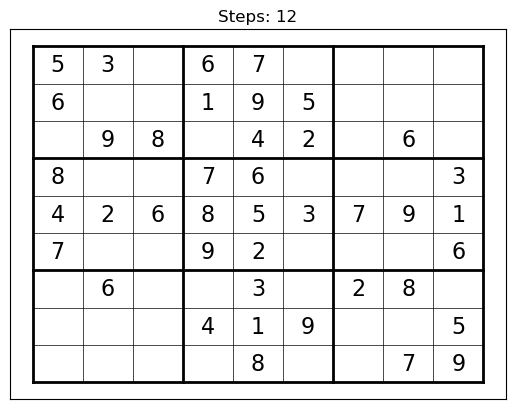

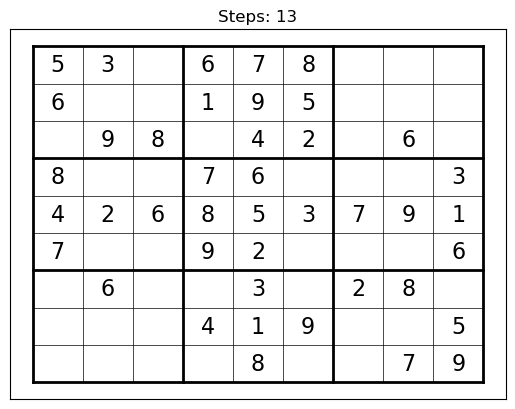

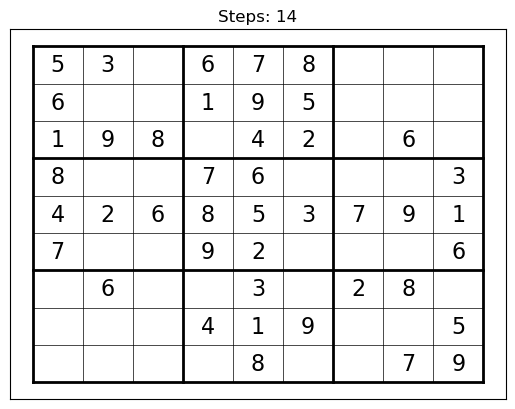

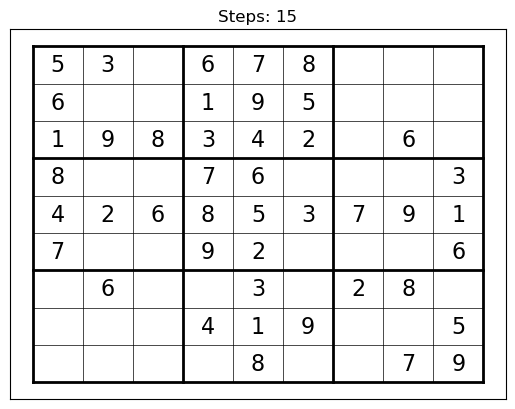

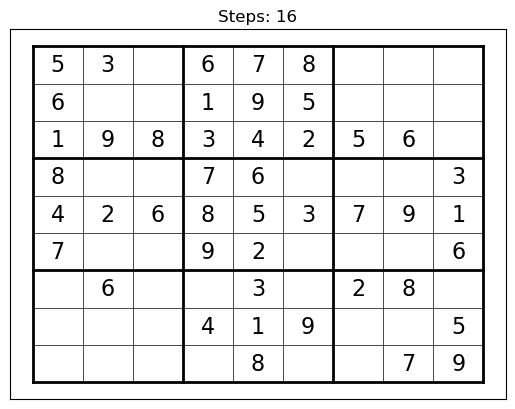

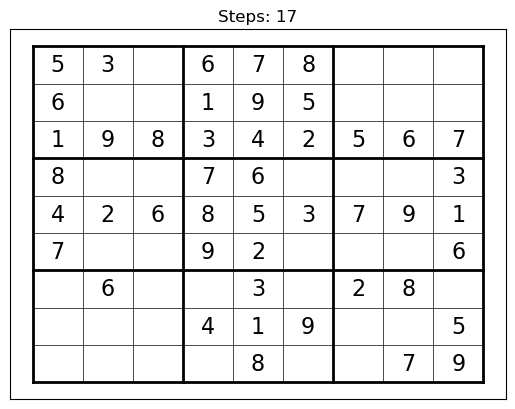

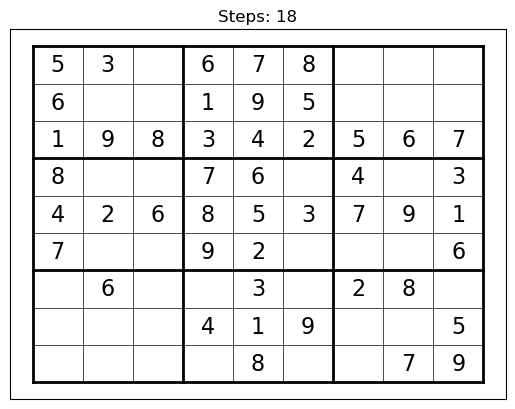

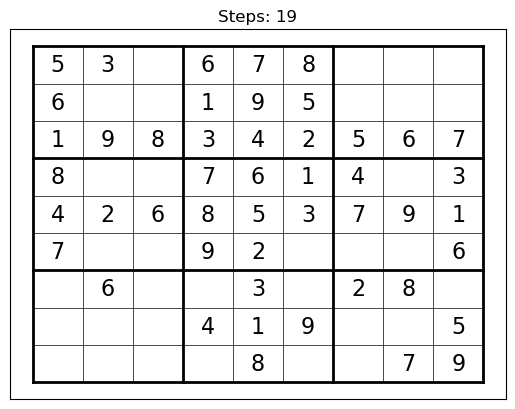

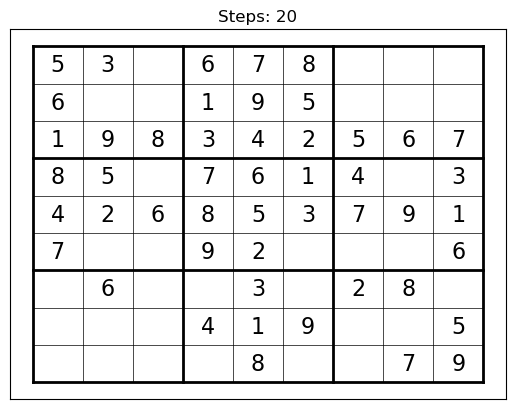

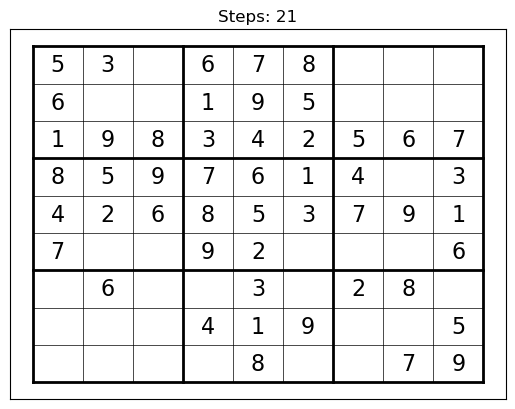

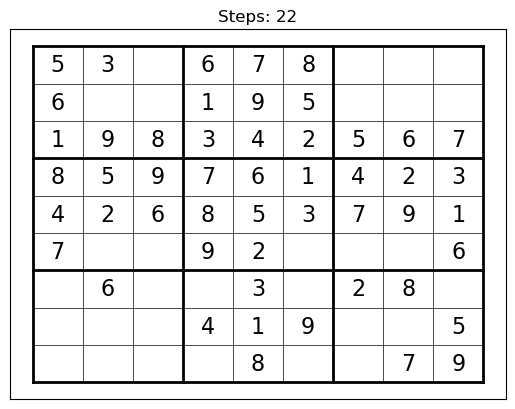

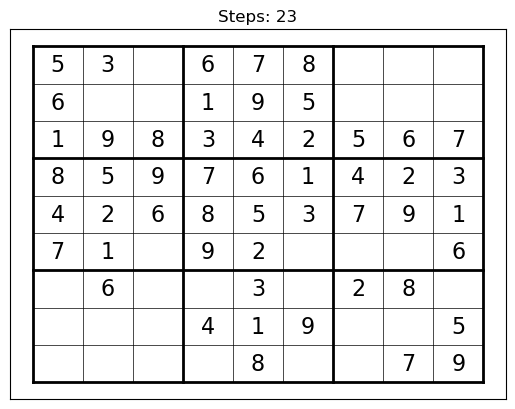

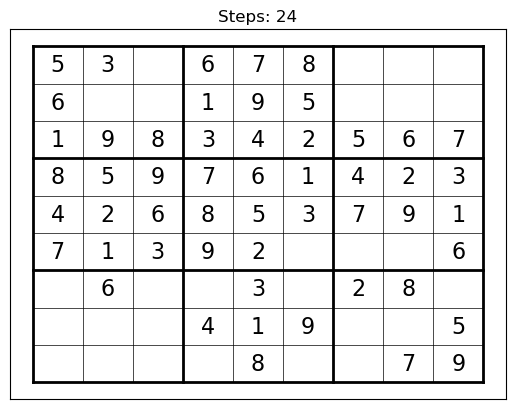

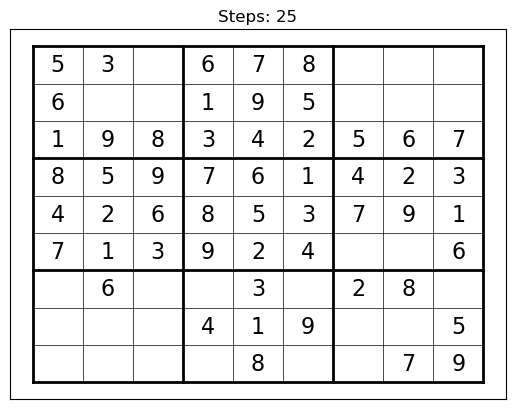

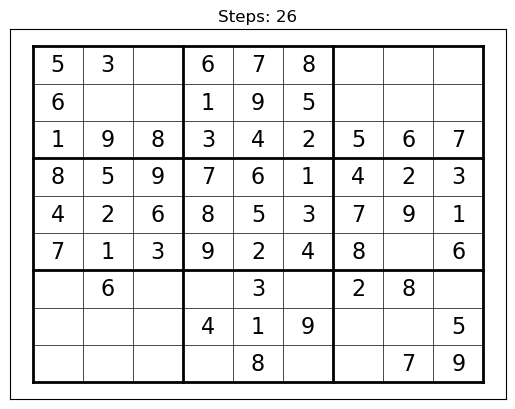

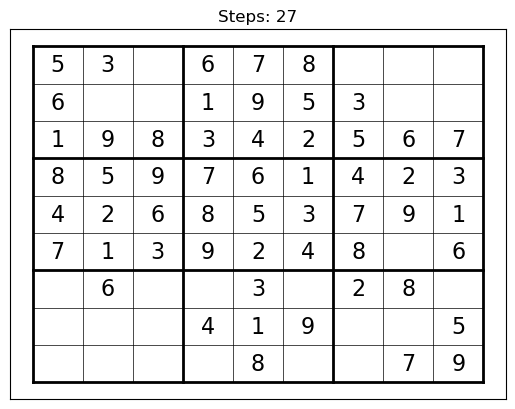

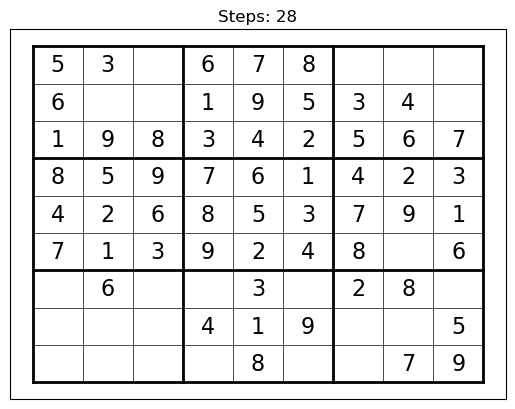

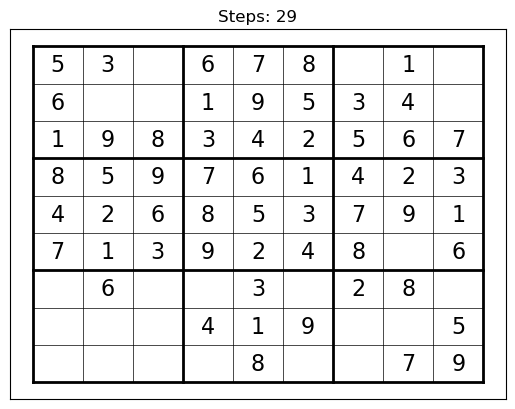

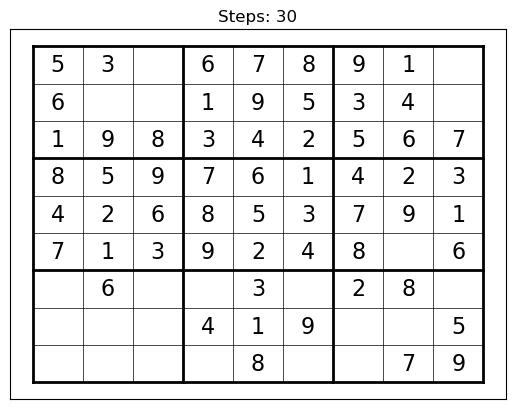

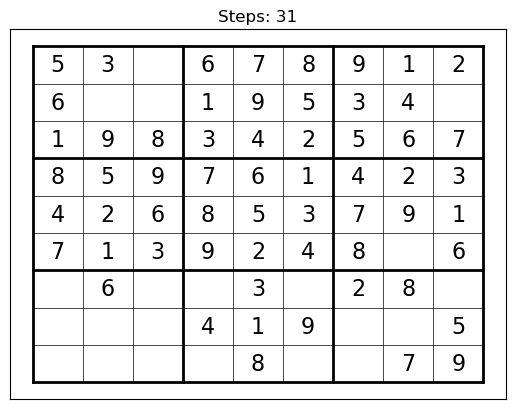

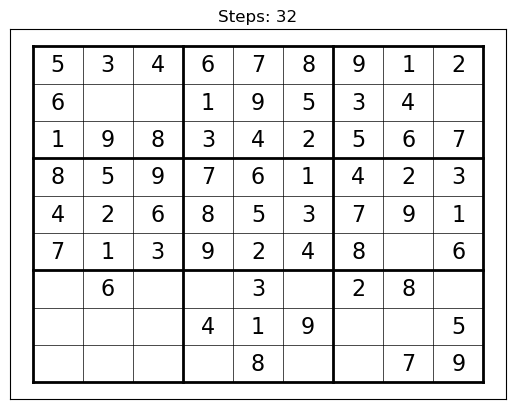

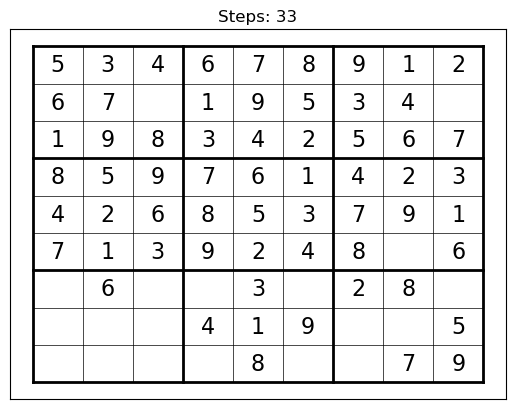

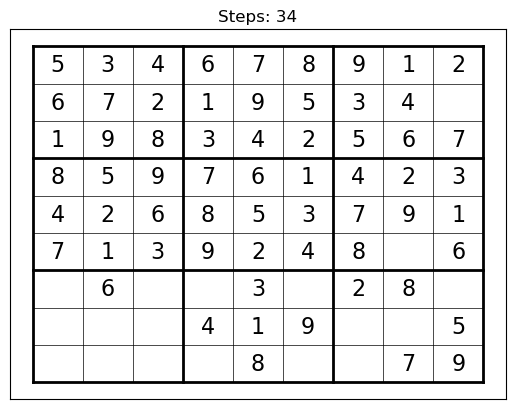

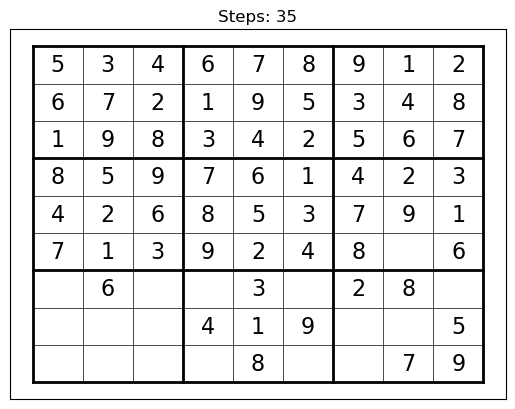

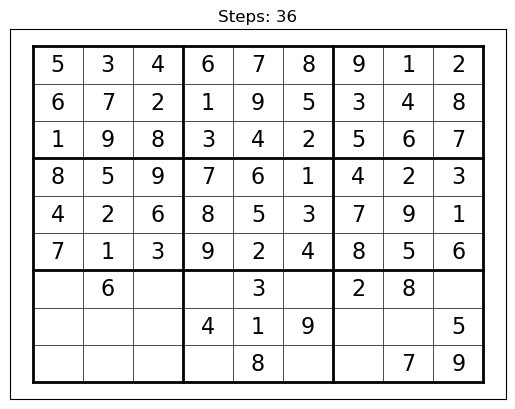

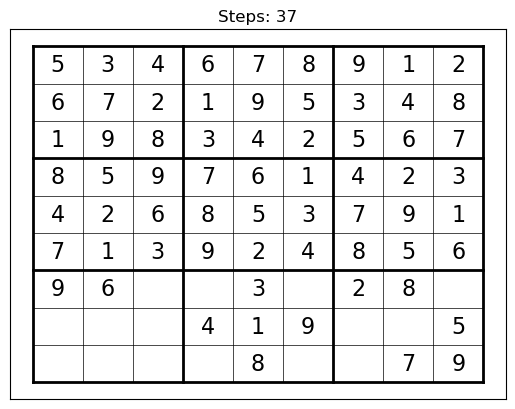

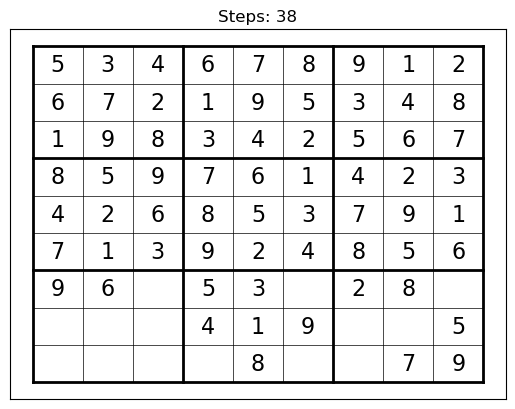

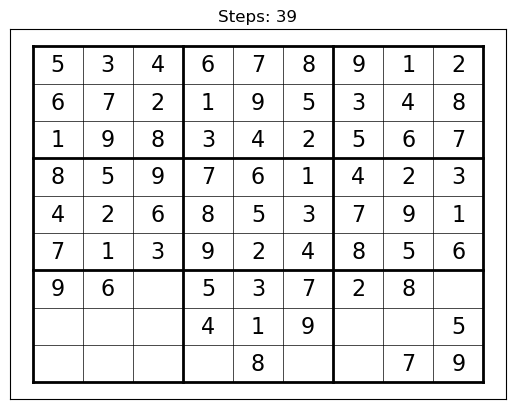

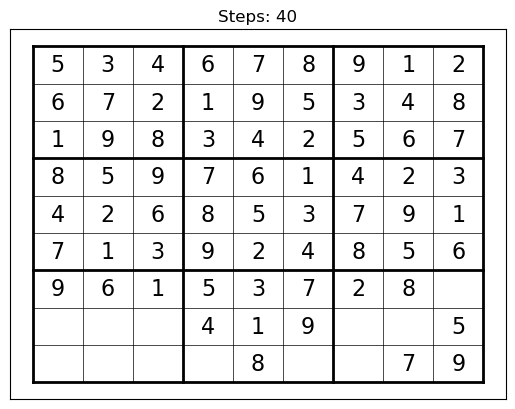

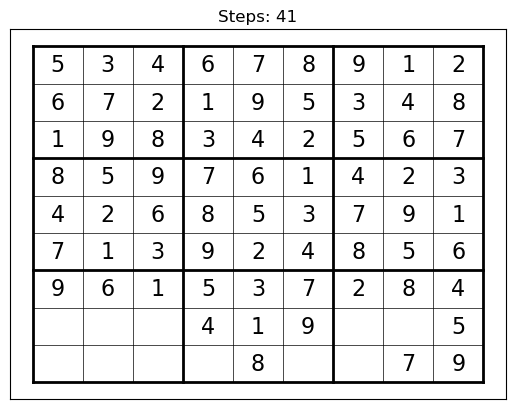

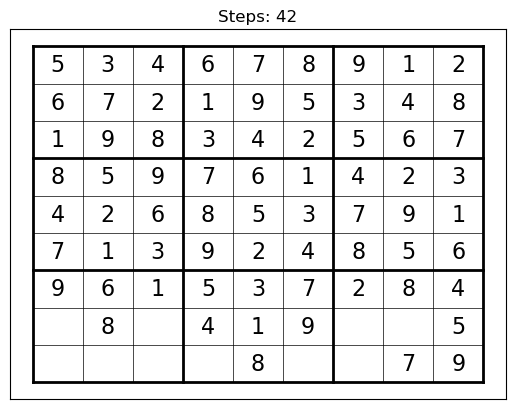

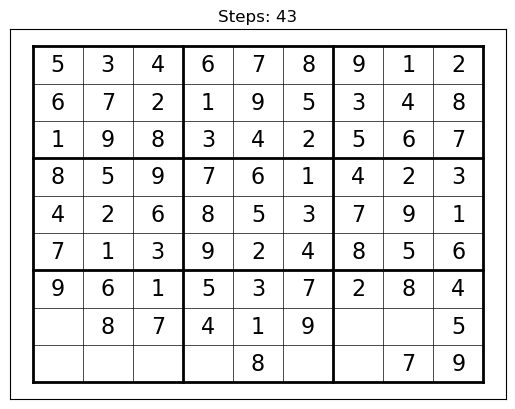

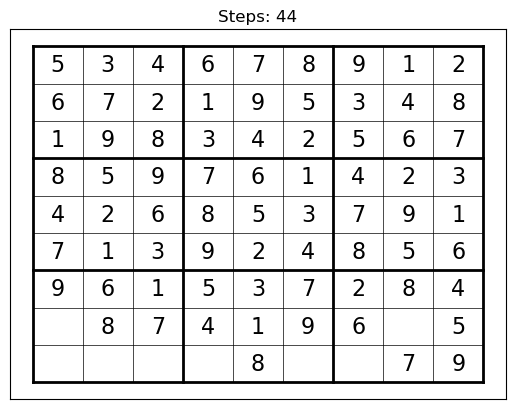

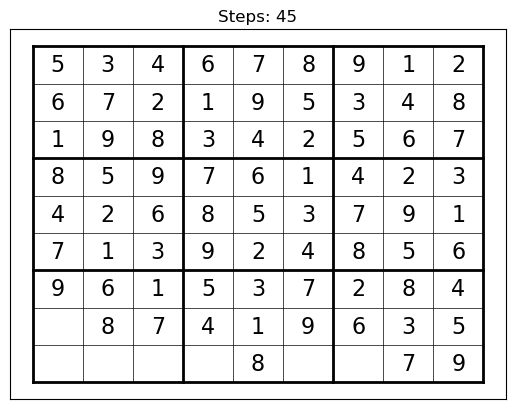

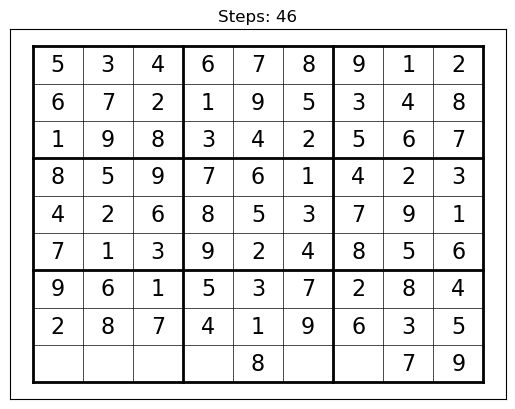

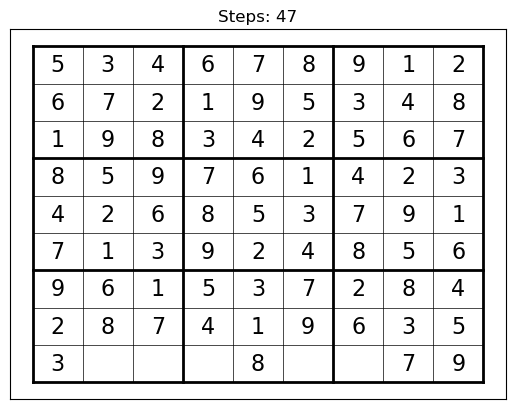

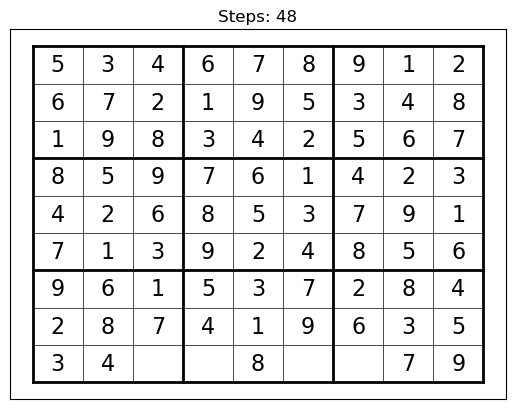

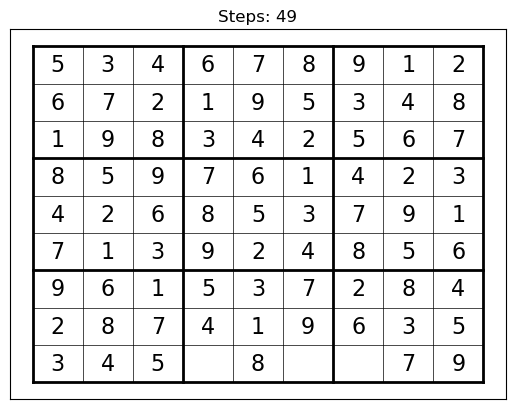

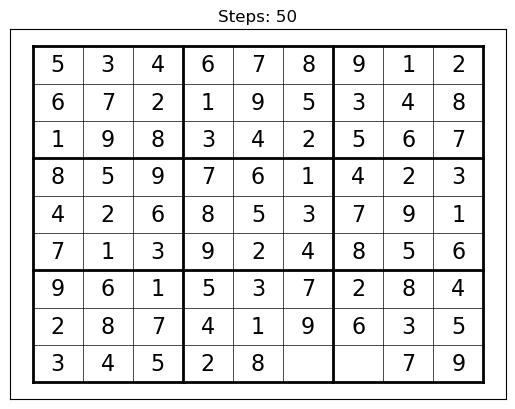

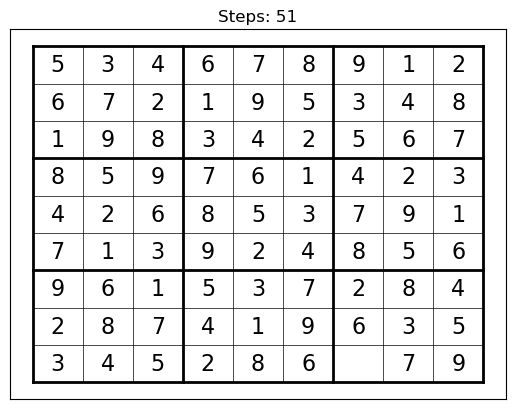

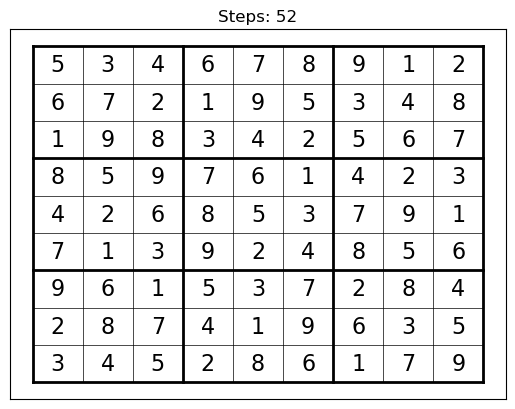

Solved Board:
[5, 3, 4, 6, 7, 8, 9, 1, 2]
[6, 7, 2, 1, 9, 5, 3, 4, 8]
[1, 9, 8, 3, 4, 2, 5, 6, 7]
[8, 5, 9, 7, 6, 1, 4, 2, 3]
[4, 2, 6, 8, 5, 3, 7, 9, 1]
[7, 1, 3, 9, 2, 4, 8, 5, 6]
[9, 6, 1, 5, 3, 7, 2, 8, 4]
[2, 8, 7, 4, 1, 9, 6, 3, 5]
[3, 4, 5, 2, 8, 6, 1, 7, 9]
Total Steps: 52


In [1]:
import matplotlib.pyplot as plt
import time

class SudokuVisualizer:
    def __init__(self, board):
        self.board = board
        self.steps = 0

    def draw(self):
        plt.clf()
        for i in range(10):
            lw = 2 if i % 3 == 0 else 0.5
            plt.plot([0,9],[i,i], 'black', linewidth=lw)
            plt.plot([i,i],[0,9], 'black', linewidth=lw)

        for i in range(9):
            for j in range(9):
                if self.board[i][j] != 0:
                    plt.text(j+0.5, 8.5-i, str(self.board[i][j]),
                             ha='center', va='center', fontsize=16)

        plt.xticks([])
        plt.yticks([])
        plt.title(f"Steps: {self.steps}")
        plt.pause(0.001)

    def is_valid(self, row, col, num):
        if num in self.board[row]:
            return False

        for i in range(9):
            if self.board[i][col] == num:
                return False

        start_row, start_col = 3*(row//3), 3*(col//3)
        for i in range(start_row, start_row+3):
            for j in range(start_col, start_col+3):
                if self.board[i][j] == num:
                    return False

        return True

    def get_domain(self, row, col):
        return [n for n in range(1,10) if self.is_valid(row, col, n)]

    def select_cell(self):
        min_domain = 10
        best = None

        for i in range(9):
            for j in range(9):
                if self.board[i][j] == 0:
                    d = self.get_domain(i, j)
                    if len(d) < min_domain:
                        min_domain = len(d)
                        best = (i, j)
        return best

    def solve(self):
        self.steps += 1
        self.draw()

        cell = self.select_cell()
        if not cell:
            return True

        r, c = cell

        for num in self.get_domain(r, c):
            if self.is_valid(r, c, num):
                self.board[r][c] = num

                if self.solve():
                    return True

                self.board[r][c] = 0

        return False


# SAMPLE BOARD
board = [
[5,3,0,0,7,0,0,0,0],
[6,0,0,1,9,5,0,0,0],
[0,9,8,0,0,0,0,6,0],
[8,0,0,0,6,0,0,0,3],
[4,0,0,8,0,3,0,0,1],
[7,0,0,0,2,0,0,0,6],
[0,6,0,0,0,0,2,8,0],
[0,0,0,4,1,9,0,0,5],
[0,0,0,0,8,0,0,7,9]
]

solver = SudokuVisualizer(board)

plt.figure(figsize=(5,5))
solver.solve()
plt.show()

print("Solved Board:")
for row in solver.board:
    print(row)
print("Total Steps:", solver.steps)